In [ ]:
  # generic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## ml libraries + breast cancer dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
cancer = load_breast_cancer()
cancer_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Check for more info on the original [dataset page](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).

In [ ]:
cancer_df.shape

(569, 30)

In [ ]:
benign = len(cancer.data[cancer.target==1])
print ("number of benign samples: ", benign)


number of benign samples:  357


In [ ]:
## how many and what are the columns

cancer_df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [ ]:
# select the features that have mean measurements;

# select the columns with names mean, error and worst
feature_mean  = list(cancer_df.columns[0:10])

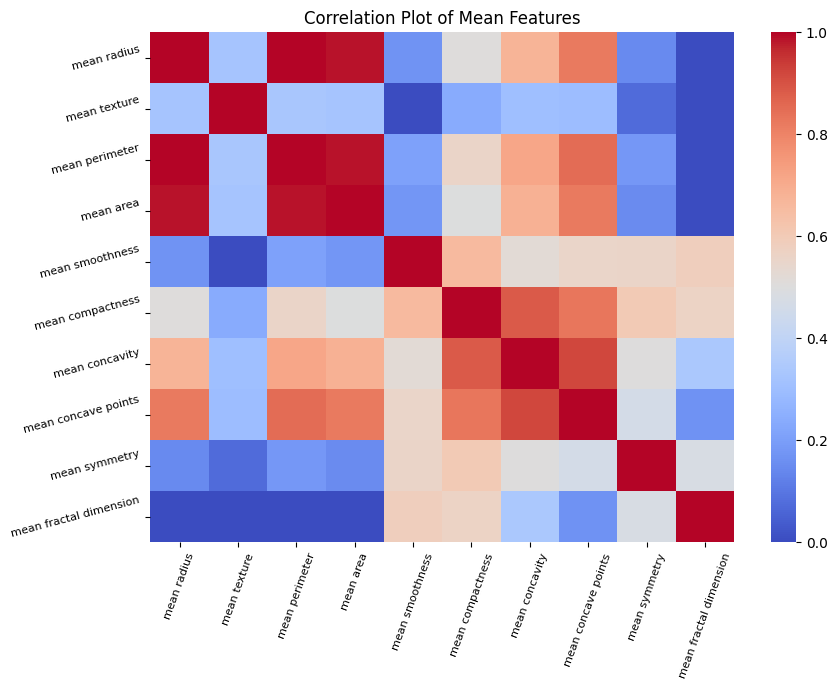

In [ ]:
mean_corr = cancer_df[feature_mean].corr()

fig=plt.figure(figsize=(9,7))
g1 = sns.heatmap(mean_corr, cmap='coolwarm', vmin=0, vmax=1)
g1.set_xticklabels(g1.get_xticklabels(), rotation=70, fontsize=8)
g1.set_yticklabels(g1.get_yticklabels(), rotation=15, fontsize=8)
plt.title("Correlation Plot of Mean Features")
plt.tight_layout()
# plt.savefig("Corr_Mean_Features.png", dpi=200)
plt.show()

<Figure size 800x500 with 0 Axes>

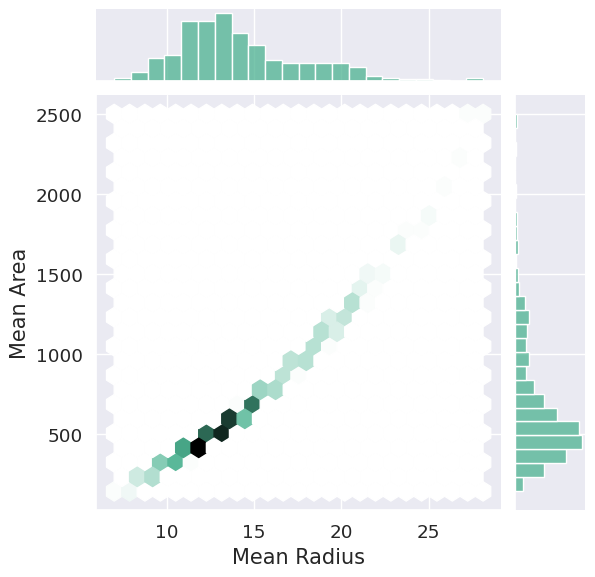

In [ ]:
sns.set(font_scale=1.2)
fig = plt.figure(figsize=(8, 5))
j = sns.jointplot(data=cancer_df,
                  x='mean radius',
                  y='mean area',
                  kind='hex',
                  color="#4CB391")

j.set_axis_labels('Mean Radius', 'Mean Area', fontsize=15)
plt.show()

#plt.savefig('Mean_Area_Radius.png', dpi=200)

In [ ]:
### let's prepare train test split

X_train, X_test, Y_train, Y_test = train_test_split(cancer.data, cancer.target, test_size=0.25,
                                                    stratify=cancer.target, random_state=30)

print ("train feature shape: ", X_train.shape)
print ("test feature shape: ", X_test.shape)
print ("train target shape: ", Y_train.shape)
print ("test target shape: ", Y_test.shape)

### standardize features

# For PCA, first scaling!!!
scaler1 = StandardScaler() # this subtracts the mean and divide by variance
scaler1.fit(cancer.data)
feature_scaled = scaler1.transform(cancer.data)

# Now Apply PCA

pca1 = PCA(n_components=4)
pca1.fit(feature_scaled)
feature_scaled_pca = pca1.transform(feature_scaled)
print("shape of the scaled and 'PCA'ed features: ", np.shape(feature_scaled_pca))


train feature shape:  (426, 30)
test feature shape:  (143, 30)
train target shape:  (426,)
test target shape:  (143,)
shape of the scaled and 'PCA'ed features:  (569, 4)


<class 'list'>


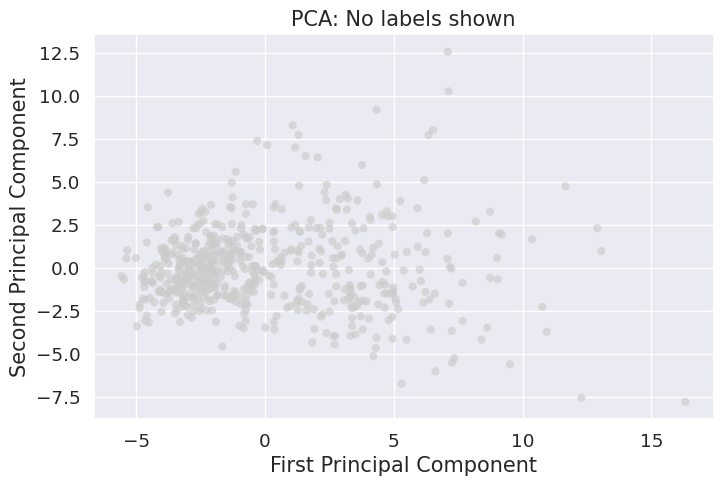

In [ ]:
#print (type(cancer.target))
cancer_target_list = cancer.target.tolist()
print (type(cancer_target_list))
#print (cancer_target_list)
#print (type(yl))
feature_scaled_pca_X0 = feature_scaled_pca[:, 0]
feature_scaled_pca_X1 = feature_scaled_pca[:, 1]
feature_scaled_pca_X2 = feature_scaled_pca[:, 2]
feature_scaled_pca_X3 = feature_scaled_pca[:, 3]

### plot the first two pca components (these two, actually the first one contains most variance)



X0 = feature_scaled_pca[:, 0]
X1 = feature_scaled_pca[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X0, X1, s=35, c="0.8", alpha=0.65, edgecolors="none")
ax.set_xlabel("First Principal Component", fontsize=15)
ax.set_ylabel("Second Principal Component", fontsize=15)
ax.set_title("PCA: No labels shown", fontsize=15)
plt.show()



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_to_folder = '/content/drive/MyDrive/Colab Notebooks/ML4Sc-Course/'


In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

### can we make a gif?

X0 = feature_scaled_pca[:, 0]
X1 = feature_scaled_pca[:, 1]
labels = np.asarray(cancer.target)
# dataframe series won't work, so we turn this into array

# --- set some colors of our choice ---
colordict = {0: 'brown', 1: 'darkslategray'}
piclabel  = {0: 'Malignant', 1: 'Benign'}
markers   = {0: 'o', 1: '*'}
sizes     = {0: 40, 1: 55}

# helper: convert to RGB arrays in [0,1]
import matplotlib.colors as mcolors
def to_rgb(c):
    return np.array(mcolors.to_rgb(c), dtype=float)
# this is necessary because our init start points are gray

gray = to_rgb("0.6")
c0 = to_rgb(colordict[0])
c1 = to_rgb(colordict[1])

# indices per class
ix0 = np.where(labels == 0)[0]
ix1 = np.where(labels == 1)[0]

# --- usual fig settings ---
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlabel("First Principal Component", fontsize=15)
ax.set_ylabel("Second Principal Component", fontsize=15)
ax.set_title("PCA: color reveal", fontsize=15)

# get to pca comps
sc0 = ax.scatter(X0[ix0], X1[ix0], s=sizes[0], c=[gray], marker=markers[0],
                 alpha=0.35, edgecolors="none", label=piclabel[0])
sc1 = ax.scatter(X0[ix1], X1[ix1], s=sizes[1], c=[gray], marker=markers[1],
                 alpha=0.35, edgecolors="none", label=piclabel[1])

# initially, we have no legends, reveal at the end
leg = None

n_frames = 130  # more number, more memory !

def lerp(a, b, t): # simple interpolation
    return a + (b - a) * t

def update(frame):
    # t goes 0 -> 1
    t = frame / (n_frames - 1)

    # color interp gray -> malignant/benign color
    col0 = lerp(gray, c0, t)
    col1 = lerp(gray, c1, t)

    sc0.set_color([col0])
    sc1.set_color([col1])

    # also slowly increase alpha, points are becoming darker
    alpha = 0.25 + 0.55 * t
    sc0.set_alpha(alpha)
    sc1.set_alpha(alpha)

    # leg. appears at ~70% of the animation
    global leg
    if leg is None and t > 0.8:
        leg = ax.legend(fontsize=13, frameon=True, loc="best")

    return sc0, sc1 # wooooooo!

ani = FuncAnimation(fig, update, frames=n_frames, interval=70, blit=False)

# save gif (needs pillow)
ani.save(path_to_folder + "/pca_color_reveal.gif", writer=PillowWriter(fps=20))
plt.close(fig)

print("Saved: pca_color_reveal.gif")


Saved: pca_color_reveal.gif
